In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. Load the saved model
model = joblib.load('../models/random_forest_fraud.pkl')

# 2. Load the data used for testing
df = pd.read_csv('../data/processed/fraud_data_final.csv')
X = df.drop(columns=['class', 'user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address', 'country', 'lower_bound_ip_address', 'upper_bound_ip_address'], errors='ignore')
y = df['class']

# We will use a small sample (e.g., 100-500 rows) for SHAP because it is computationally expensive
X_sample = X.sample(500, random_state=42)

C:\Users\DELL 7020\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Create the Explainer
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# Note: For Random Forest, shap_values is a list. 
# shap_values[1] refers to the 'Fraud' class (1).

Final SHAP shape: (500, 13)
Final Data shape: (500, 13)


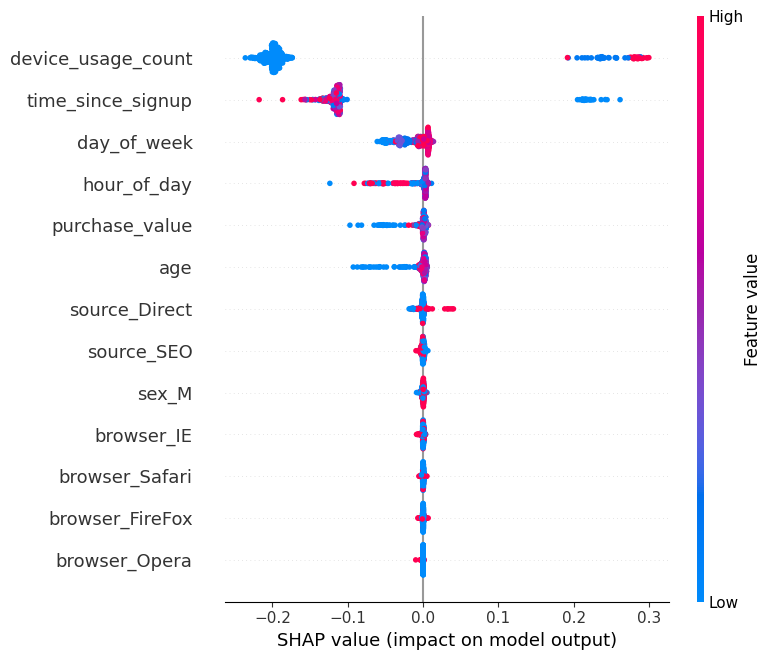

In [3]:
import shap
import numpy as np

# 1. Ensure we are using the exact features the model was trained on
model_features = model.feature_names_in_
X_clean_sample = X_sample[model_features].copy().reset_index(drop=True)

# 2. Recalculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_clean_sample)

# 3. FIX THE SHAPE (The "Flattening" Step)
# If the shape is (500, 13, 2), we need to extract only the values for Class 1 (Fraud)
# We select the last index [:, :, 1]
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    # If it's a list, check if the inner array is 3D or 2D
    if len(shap_values[1].shape) == 3:
        shap_to_plot = shap_values[1][:, :, 1] # Select Class 1 and the main effect
    else:
        shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

# 4. Final print check to be 100% sure before plotting
print(f"Final SHAP shape: {shap_to_plot.shape}")
print(f"Final Data shape: {X_clean_sample.shape}")

# 5. RUN THE PLOT
shap.summary_plot(shap_to_plot, X_clean_sample)


--- True Positive: Correctly Identified Fraud (Index: 137399) ---


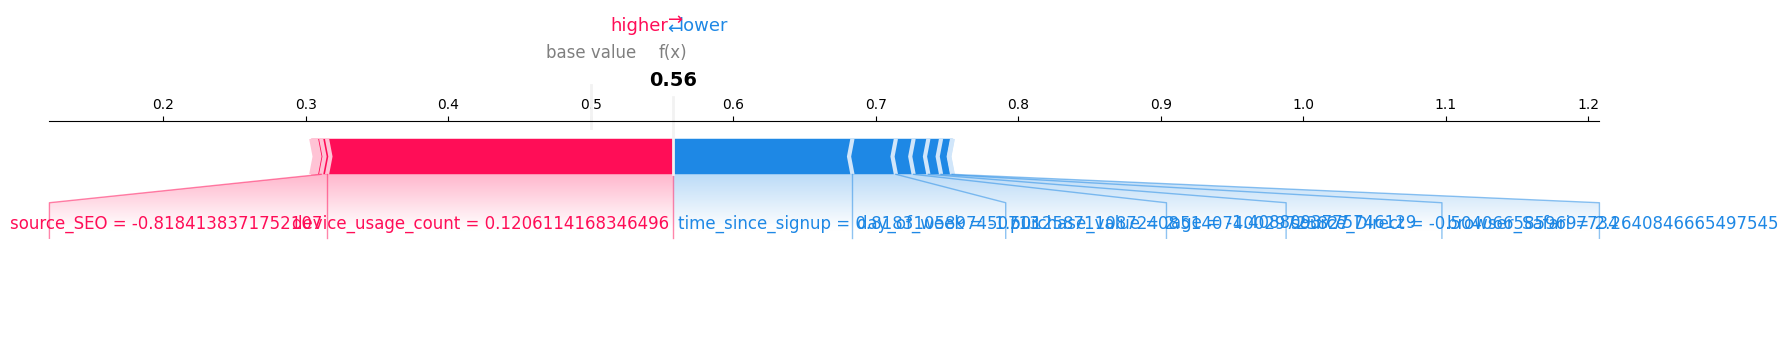


--- False Positive: Legitimate Flagged as Fraud (Index: 29219) ---


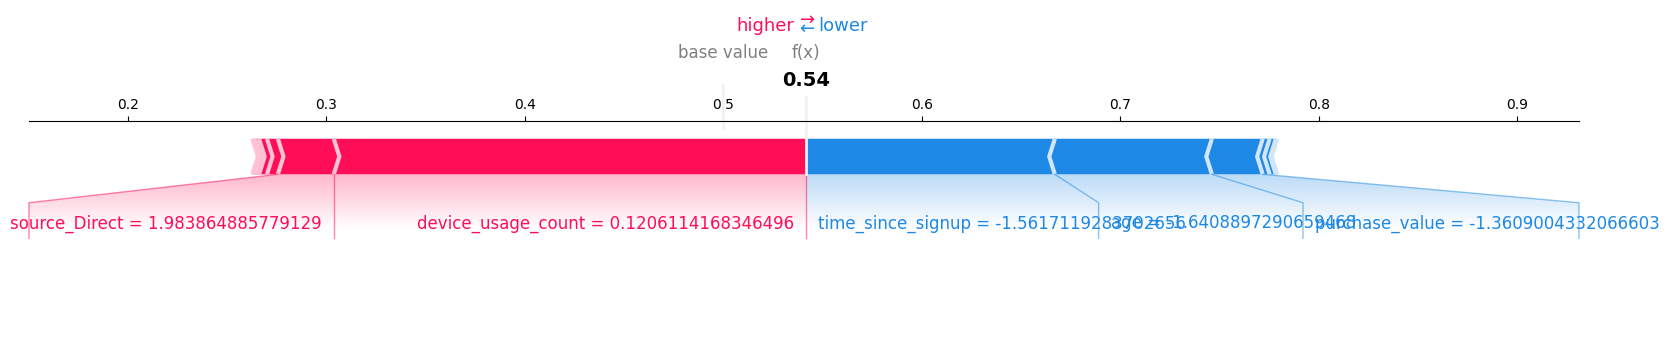


--- False Negative: Missed Fraud (Index: 3763) ---


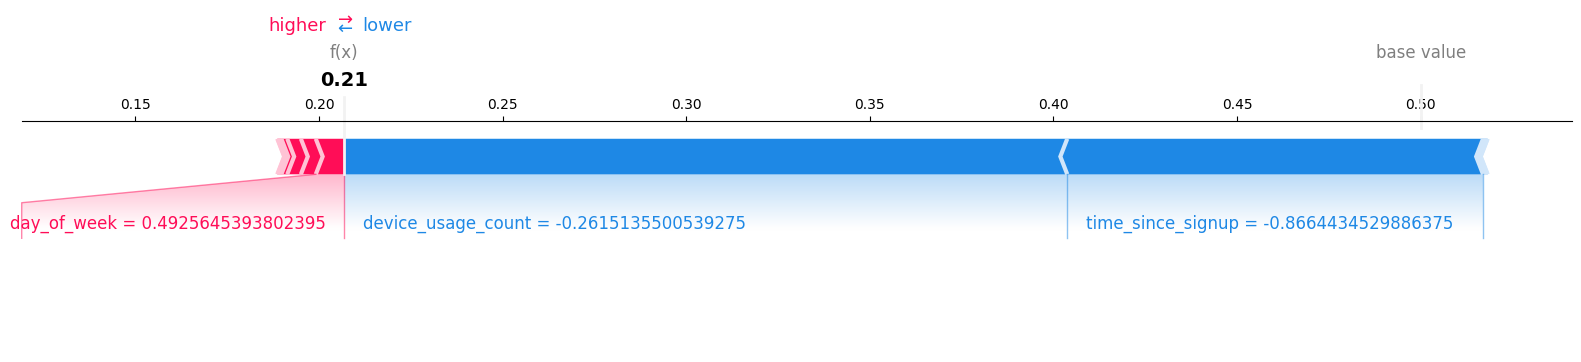

In [7]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Load Model and identify features
model = joblib.load('../models/random_forest_fraud.pkl')
model_features = list(model.feature_names_in_)

# 2. Load Data and Split (to define X_test)
df = pd.read_csv('../data/processed/fraud_data_final.csv')
X = df[model_features] # Use only columns model knows
y = df['class']

# Re-create the same split used in modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Setup SHAP Explainer
explainer = shap.TreeExplainer(model)

# 4. Identify the 3 required business cases
y_pred = model.predict(X_test)
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred}, index=X_test.index)

# Find indices
tp_idx = results[(results['actual'] == 1) & (results['predicted'] == 1)].index[0] # Correct Fraud
fp_idx = results[(results['actual'] == 0) & (results['predicted'] == 1)].index[0] # False Alarm
fn_idx = results[(results['actual'] == 1) & (results['predicted'] == 0)].index[0] # Missed Fraud

# 5. Helper function to plot correctly and avoid DimensionError
def safe_force_plot(idx, title):
    print(f"\n--- {title} (Index: {idx}) ---")
    row = X_test.loc[[idx]]
    sv = explainer.shap_values(row)
    
    # Handle the Class 1 (Fraud) extraction
    if isinstance(sv, list):
        clean_sv = sv[1][0, :]
    elif len(sv.shape) == 3:
        clean_sv = sv[0, :, 1]
    else:
        clean_sv = sv[0, :]

    return shap.force_plot(
        explainer.expected_value[1], 
        clean_sv, 
        row, 
        matplotlib=True
    )

# 6. Generate the 3 Plots
shap.initjs()
safe_force_plot(tp_idx, "True Positive: Correctly Identified Fraud")
safe_force_plot(fp_idx, "False Positive: Legitimate Flagged as Fraud")
safe_force_plot(fn_idx, "False Negative: Missed Fraud")

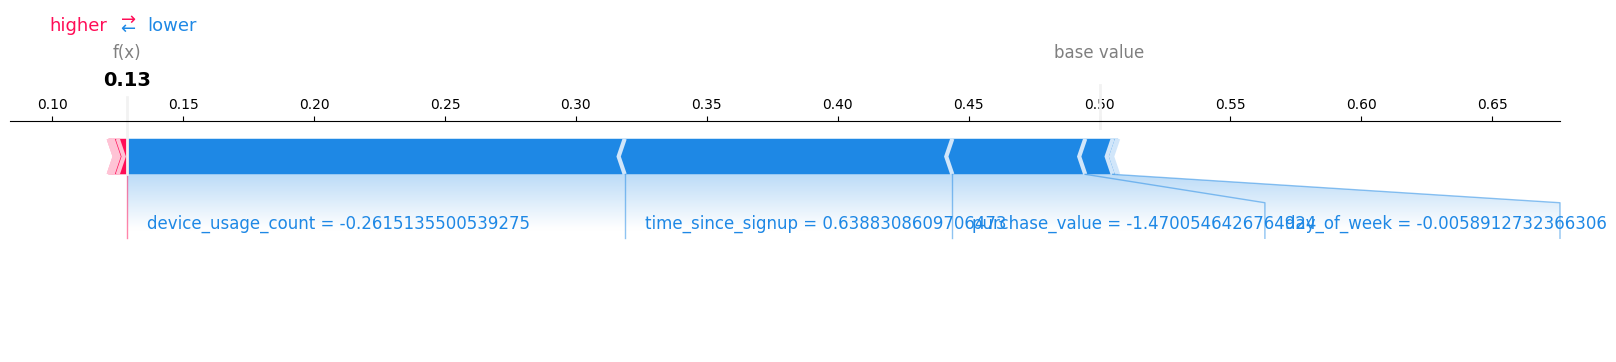

In [4]:
# Initialize JS for plots
shap.initjs()

# Function to get a specific prediction type
def get_prediction_index(y_test, y_pred, target_class):
    # Find indices where the prediction matches our target (e.g., predicted Fraud)
    indices = np.where((y_pred == target_class))[0]
    return indices[0] # Return the first one found

# Let's pick a specific instance from our sample
# Instance 0
instance_index = 0
shap.force_plot(
    explainer.expected_value[1], 
    shap_to_plot[instance_index,:], 
    X_clean_sample.iloc[instance_index,:], 
    matplotlib=True
)

In [8]:
from sklearn.metrics import confusion_matrix

# 1. Get predictions for the test set
# We need to make sure we use the features the model knows
X_test_clean = X_test[model_features]
y_pred = model.predict(X_test_clean)

# 2. Identify the categories
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred})

# Correctly identified fraud
true_positives = results[(results['actual'] == 1) & (results['predicted'] == 1)].index[0]

# Legitimate flagged as fraud
false_positives = results[(results['actual'] == 0) & (results['predicted'] == 1)].index[0]

# Fraud that was missed
false_negatives = results[(results['actual'] == 1) & (results['predicted'] == 0)].index[0]

print(f"Index for True Positive: {true_positives}")
print(f"Index for False Positive: {false_positives}")
print(f"Index for False Negative: {false_negatives}")

Index for True Positive: 137399
Index for False Positive: 29219
Index for False Negative: 3763
